# Calling malignant cells from the inferCNV residuals

Third step of 05_1, and the one where a decision is taken. `infercnv_all.sh` has already run
inferCNV once per cohort and reduced each run to a per-cell table; nothing there thresholds
anything. This notebook looks at those tables, picks the rule that separates malignant from
non-malignant, and writes the call out as metadata.

**The two axes.** Copy-number magnitude alone does not identify a tumour cell: a cell with a
noisy, shallow transcriptome has a large mean squared residual everywhere, and looks exactly
like an aneuploid cell if that is all you measure. The standard fix (Puram et al. 2017,
Neftel et al. 2019) is to add a second axis - how much the cell's residual profile *correlates*
with the profile of the cohort's most-aneuploid cells. Noise is uncorrelated; a shared
karyotype is not. `run_infercnv.R` computed both:

- `cnv_score` - mean squared residual against the mean profile of that run's immune reference,
- `cnv_corr` - Pearson correlation with the mean residual profile of the top 5% of epithelial
  cells by `cnv_score` in that cohort.

**Where the thresholds come from.** Both axes are on a scale that is specific to the cohort:
it depends on that patient's sequencing depth, on how many reference cells there were and on
how strong the clone is. A single global cut would therefore call more cells malignant in a
deeply sequenced patient than in a shallow one. Instead every cohort carries its own null:
the **stromal block**, fibroblasts and endothelium passed through the run as observations, not
as reference, so smoothed and denoised identically to the epithelium and expected to be
diploid. The cut is a quantile of that block, per cohort.

That leaves the immune reference cells (`ref_tcell`, `ref_myeloid`) completely unused by the
rule, which makes them a genuinely independent specificity check: they did not set the
threshold, so the rate at which they cross it is a measurement rather than a tautology.

Output: `$DATA_DIR/05_tum/cnv_status.csv`, one row per cell **of `shiao.h5ad`** -
`malignant`, `non_malignant` or `not_tested` - which `recelltypist_nonmalignant.py` reads next.


## Packages and paths


In [2]:
# Core scverse libraries
from __future__ import annotations

# Main
import anndata as ad
import pandas as pd
import numpy as np
import os
import glob

# Plotting
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D
import seaborn as sns

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['figure.facecolor'] = 'white'

try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()  # interactive fallback
PHASE_DIR = os.path.dirname(SCRIPT_DIR)  # 04_drvi_epithelial/

FIG_DIR = os.environ.get('FIG_DIR', os.path.join(PHASE_DIR, 'figures', '05_1_infercnv'))
os.makedirs(FIG_DIR, exist_ok=True)

TABLE_DIR = os.environ.get('TABLE_DIR', os.path.join(PHASE_DIR, 'tables', '05_1_infercnv'))
os.makedirs(TABLE_DIR, exist_ok=True)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

print('FIG_DIR  :', FIG_DIR)
print('TABLE_DIR:', TABLE_DIR)

FIG_DIR  : /home/albertoc/Desktop/QCB-Master-Thesis/05_drvi_tumoral_epi/figures/05_1_infercnv
TABLE_DIR: /home/albertoc/Desktop/QCB-Master-Thesis/05_drvi_tumoral_epi/tables/05_1_infercnv


In [3]:
DATA_DIR = os.environ.get('DATA_DIR', '').strip() or os.path.join(os.path.dirname(PHASE_DIR), 'datasets')
DATA_DIR = os.path.abspath(os.path.expanduser(DATA_DIR))
CNV_DIR = os.path.join(DATA_DIR, '05_tum')
SUMMARY_DIR = os.path.join(CNV_DIR, 'summary')

SHIAO_H5AD = os.path.join(DATA_DIR, 'shiao.h5ad')       # only .obs is read, backed
STATUS_OUT = os.path.join(CNV_DIR, 'cnv_status.csv')    # what this notebook writes

print('DATA_DIR:', DATA_DIR)
print('summaries:', SUMMARY_DIR, '| exists:', os.path.isdir(SUMMARY_DIR))
print('output  :', STATUS_OUT)

GROUP_EPI = 'epi'
GROUP_STROMAL = 'stromal'
REF_GROUPS = ('ref_tcell', 'ref_myeloid')

# Colour per group, used in every figure below.
GROUP_COLORS = {'epi': '#2f7d4f', 'stromal': '#d19a34', 'ref_tcell': '#5f7fb0', 'ref_myeloid': '#8d6ca8'}

DATA_DIR: /home/albertoc/Desktop/QCB-Master-Thesis/datasets
summaries: /home/albertoc/Desktop/QCB-Master-Thesis/datasets/05_tum/summary | exists: True
output  : /home/albertoc/Desktop/QCB-Master-Thesis/datasets/05_tum/cnv_status.csv


## The per-cell tables


In [4]:
paths = sorted(glob.glob(os.path.join(SUMMARY_DIR, '*_cnv.csv')))
assert paths, f'no summaries in {SUMMARY_DIR}: run ./infercnv_all.sh first'
cnv = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)

print(f'{len(paths)} cohort(s), {len(cnv):,} cells')
cnv['group'] = pd.Categorical(cnv['group'], categories=[GROUP_EPI, GROUP_STROMAL, *REF_GROUPS])
cnv.groupby('group', observed=True).size()

33 cohort(s), 165,054 cells


group
epi            75438
stromal        25574
ref_tcell      32928
ref_myeloid    31114
dtype: int64

In [5]:
# The census says which cohorts were prepared and which were skipped for having too little
# epithelium; compare it against what actually produced a summary, so a cohort that failed
# inside inferCNV is visible here rather than silently absent from the call.
census = pd.read_csv(os.path.join(CNV_DIR, 'cohort_census.csv'))
ran = set(cnv['cohort'].unique())
prepared = set(census.loc[census['status'] == 'prepared', 'cohort'])
skipped = set(census.loc[census['status'] != 'prepared', 'cohort'])

print(f'prepared: {len(prepared)} | with a summary: {len(ran)} | skipped upfront: {sorted(skipped)}')
missing = sorted(prepared - ran)
if missing:
    print('PREPARED BUT NO SUMMARY (inferCNV failed on these):', missing)

prepared: 32 | with a summary: 33 | skipped upfront: ['Patient06']


In [6]:
cnv.groupby(['group'], observed=True)[['cnv_score', 'cnv_corr']].describe().round(4).T

group                   epi     stromal   ref_tcell  ref_myeloid
cnv_score count  75438.0000  25574.0000  32928.0000   31114.0000
          mean       0.0023      0.0010      0.0008       0.0005
          std        0.0021      0.0006      0.0005       0.0005
          min        0.0000      0.0000      0.0000       0.0000
          25%        0.0010      0.0006      0.0004       0.0002
          50%        0.0019      0.0009      0.0007       0.0004
          75%        0.0030      0.0013      0.0010       0.0007
          max        0.2929      0.0201      0.0066       0.0048
cnv_corr  count  75438.0000  25574.0000  32928.0000   31114.0000
          mean       0.4922      0.1261     -0.0002      -0.0204
          std        0.2655      0.1451      0.1005       0.1325
          min       -0.4064     -0.3704     -0.5842      -0.5253
          25%        0.2892      0.0323     -0.0664      -0.0965
          50%        0.5441      0.1099     -0.0034      -0.0201
          75%        0.7171      0.1987      0.0613       0.0559
          max        0.9582      0.8681      0.7817       0.7637

## The two axes, pooled

The first thing to look at is whether the four groups separate at all. The reference cells set
the floor of both axes by construction (`cnv_score` is defined against their mean), so what
matters is the gap between `epi` and `stromal`: stromal cells went through the same pipeline
with no special status, and they are the population the epithelium has to be distinguished
*from*.


<Axes: xlabel='cnv_score', ylabel='Density'>

<Axes: xlabel='cnv_score', ylabel='Density'>

<Axes: xlabel='cnv_score', ylabel='Density'>

<Axes: xlabel='cnv_score', ylabel='Density'>

Text(0.5, 0, 'CNV score (mean squared residual)')

...

<Axes: xlabel='cnv_corr', ylabel='Density'>

<Axes: xlabel='cnv_corr', ylabel='Density'>

Text(0.5, 0, 'CNV correlation with the top-CNV profile')

Text(0, 0.5, 'density')

Text(0.5, 1.02, 'inferCNV: the two axes, all cohorts pooled')

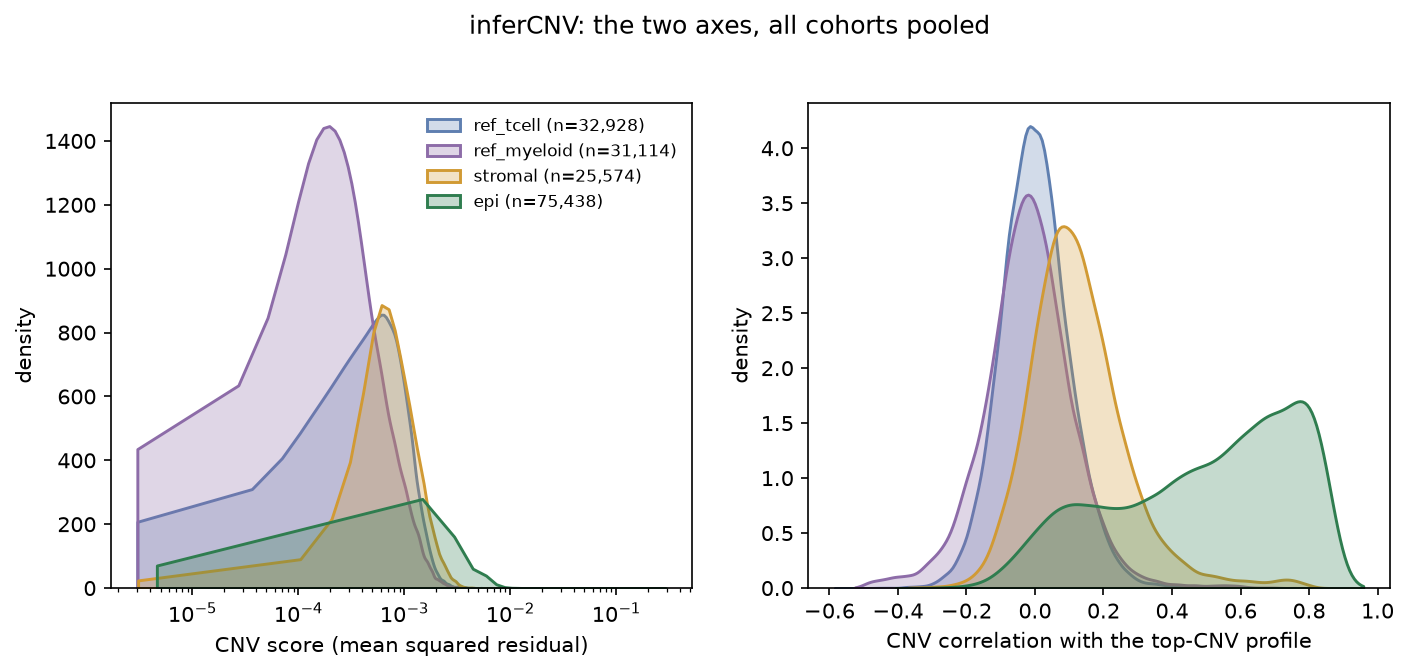

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, col, label in zip(axes, ['cnv_score', 'cnv_corr'],
                          ['CNV score (mean squared residual)', 'CNV correlation with the top-CNV profile']):
    for g in [*REF_GROUPS, GROUP_STROMAL, GROUP_EPI]:
        v = cnv.loc[cnv['group'] == g, col]
        sns.kdeplot(x=v, ax=ax, fill=True, alpha=.28, linewidth=1.4,
                    color=GROUP_COLORS[g], label=f'{g} (n={len(v):,})', clip=(v.min(), v.max()))
    ax.set_xlabel(label); ax.set_ylabel('density')
axes[0].set_xscale('log')
axes[0].legend(frameon=False, fontsize=8)
axes[1].legend().remove()
fig.suptitle('inferCNV: the two axes, all cohorts pooled', y=1.02)
fig.savefig(os.path.join(FIG_DIR, 'cnv_axes_pooled.png'))
plt.show()

Text(0.5, 0, 'CNV score')

Text(0, 0.5, 'CNV correlation')

Text(0.5, 1.0, 'CNV score x correlation, all cohorts pooled')

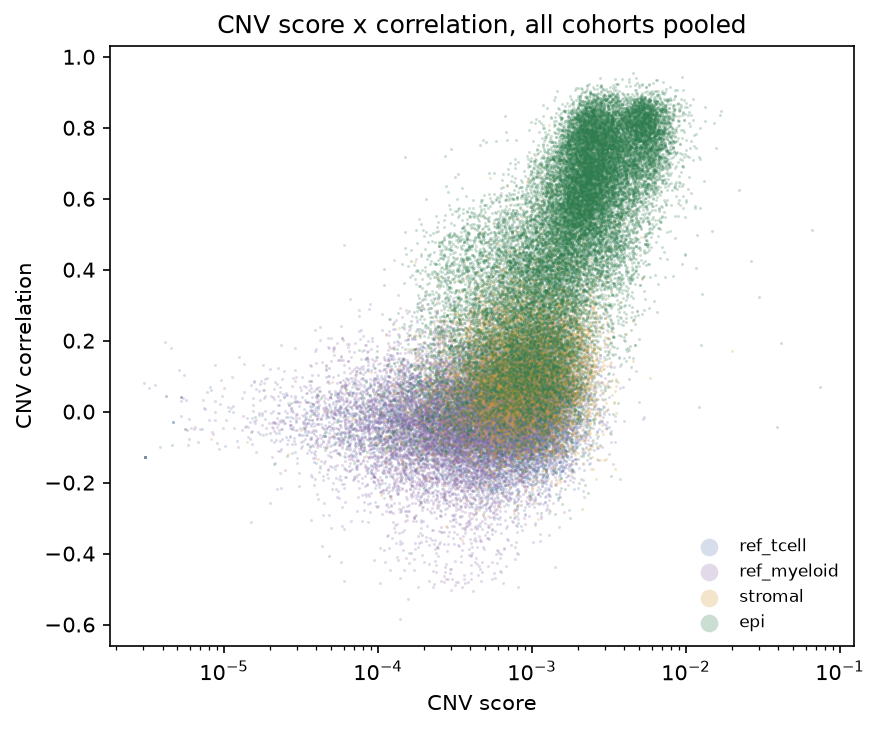

In [8]:
# The joint view. Every published version of this call is read off a plot like this one:
# the malignant cells are the upper-right cloud, the diploid cells the lower-left one.
fig, ax = plt.subplots(figsize=(6.4, 5.2))
sub = cnv.sample(min(len(cnv), 60_000), random_state=0)
for g in [*REF_GROUPS, GROUP_STROMAL, GROUP_EPI]:
    d = sub[sub['group'] == g]
    ax.scatter(d['cnv_score'], d['cnv_corr'], s=2, alpha=.25, linewidths=0,
               color=GROUP_COLORS[g], label=g, rasterized=True)
ax.set_xscale('log')
ax.set_xlabel('CNV score'); ax.set_ylabel('CNV correlation')
ax.set_title('CNV score x correlation, all cohorts pooled')
ax.legend(frameon=False, markerscale=6, fontsize=8, loc='lower right')
fig.savefig(os.path.join(FIG_DIR, 'cnv_scatter_pooled.png'), dpi=200)
plt.show()

## Why the cut cannot be global

Pooled, the two clouds overlap more than they do inside any single patient. That overlap is
mostly between-cohort: the panel below puts the `epi` and `stromal` blocks of each cohort side
by side, and the position of both moves together from patient to patient. A horizontal line
drawn across this figure would be a different quantile of the null in every column.


<Axes: xlabel='cohort', ylabel='cnv_score'>

Text(0, 0.5, 'CNV score')

Text(0.5, 0, '')

Text(0.5, 1.0, 'Epithelium vs its own stromal null, per cohort (cohorts ordered by median epithelial score)')

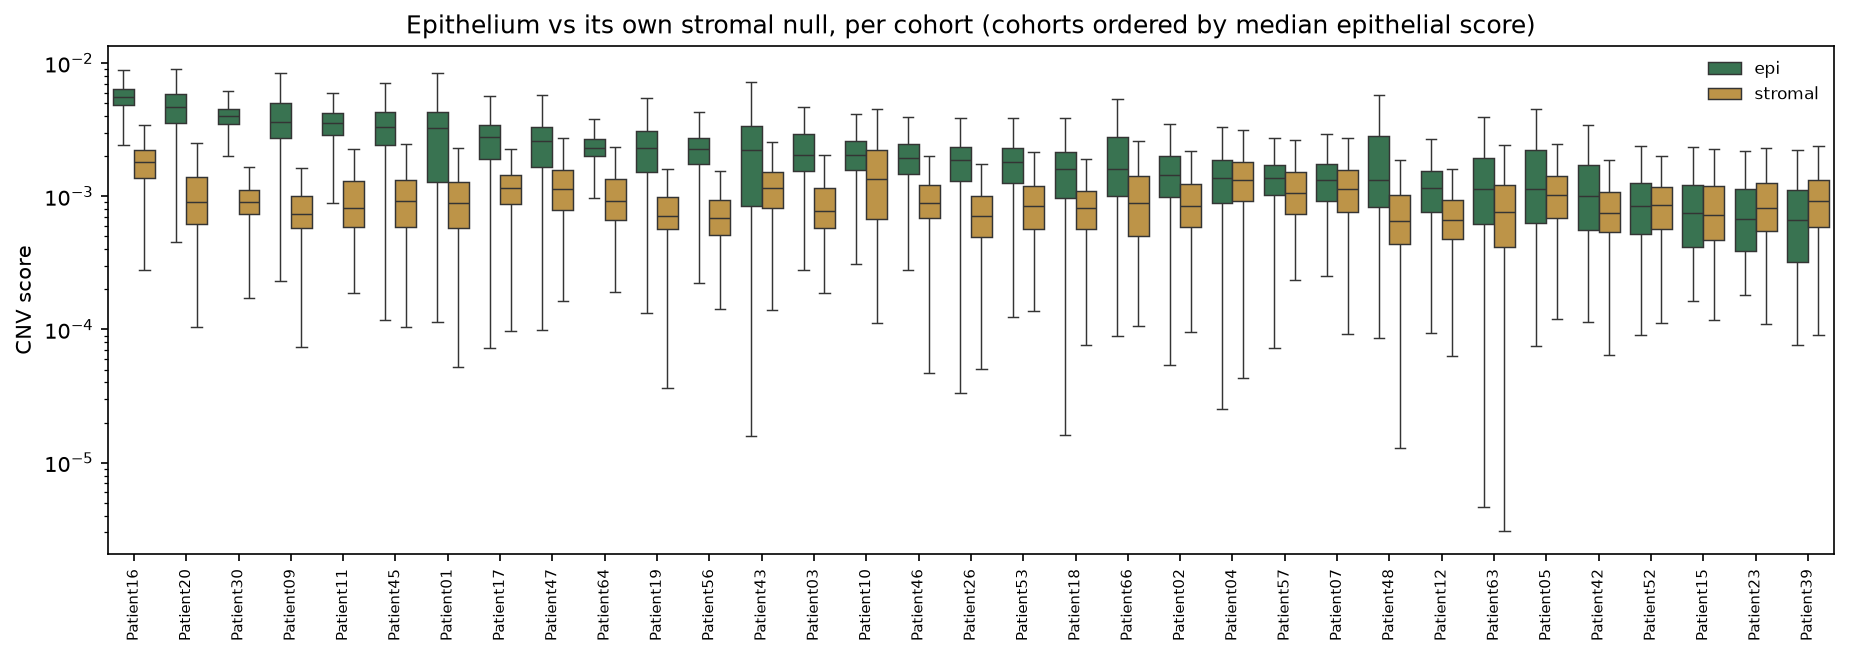

In [9]:
order = (cnv[cnv['group'] == GROUP_EPI].groupby('cohort')['cnv_score'].median()
         .sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(max(9, .45 * len(order)), 4.4))
# hue_order is explicit: 'group' is a Categorical carrying the two reference levels too,
# and seaborn reads the levels off the dtype rather than off the rows actually passed.
sns.boxplot(data=cnv[cnv['group'].isin([GROUP_EPI, GROUP_STROMAL])],
            x='cohort', y='cnv_score', hue='group', order=order,
            hue_order=[GROUP_EPI, GROUP_STROMAL], showfliers=False,
            palette={GROUP_EPI: GROUP_COLORS[GROUP_EPI], GROUP_STROMAL: GROUP_COLORS[GROUP_STROMAL]},
            linewidth=.7, ax=ax)
ax.set_yscale('log')
ax.set_ylabel('CNV score'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.legend(frameon=False, fontsize=8, title=None)
ax.set_title('Epithelium vs its own stromal null, per cohort (cohorts ordered by median epithelial score)')
fig.savefig(os.path.join(FIG_DIR, 'cnv_score_by_cohort.png'))
plt.show()

## The rule

Per cohort, a cell is called **malignant** when it is above the stromal null on **both** axes:

```
cnv_score > quantile(cnv_score of that cohort's stromal cells, Q)
        and
cnv_corr  > quantile(cnv_corr  of that cohort's stromal cells, Q)
```

with `Q = 0.95`. Only epithelial cells are eligible: stromal and immune cells are the controls,
and calling one of them malignant would be a statement this design cannot support (a fibroblast
above the cut is evidence about the *threshold*, not about that fibroblast).

`Q` is the one number to move. Raising it makes the call more conservative - fewer malignant
cells, and the epithelium left behind is more certainly diploid, which is what matters for a
re-annotation against a normal-breast model. The specificity check below is what to read when
changing it.


In [10]:
Q = 0.95        # quantile of the per-cohort stromal null that sets both cuts
MIN_NULL = 30   # a cohort with fewer stromal cells than this cannot define its own null

# Cohorts whose stromal block is too thin fall back to the pooled stromal quantile, scaled by
# how that cohort's reference cells compare to the pooled reference. Without the rescaling the
# fallback would ignore exactly the between-cohort shift the previous figure showed.
stromal = cnv[cnv['group'] == GROUP_STROMAL]
refs = cnv[cnv['group'].isin(REF_GROUPS)]

n_null = stromal.groupby('cohort').size()
thin = sorted(n_null[n_null < MIN_NULL].index) + sorted(set(cnv['cohort'].unique()) - set(n_null.index))
print(f'cohorts with a usable stromal null: {(n_null >= MIN_NULL).sum()}')
print(f'cohorts falling back to the pooled null: {thin if thin else "none"}')

pooled_cut = {'cnv_score': stromal['cnv_score'].quantile(Q), 'cnv_corr': stromal['cnv_corr'].quantile(Q)}
pooled_ref_med = refs['cnv_score'].median()

rows = []
for cohort, d in cnv.groupby('cohort', observed=True):
    d_str = d[d['group'] == GROUP_STROMAL]
    if len(d_str) >= MIN_NULL:
        cut_score, cut_corr, source = d_str['cnv_score'].quantile(Q), d_str['cnv_corr'].quantile(Q), 'own'
    else:
        scale = d[d['group'].isin(REF_GROUPS)]['cnv_score'].median() / pooled_ref_med
        cut_score, cut_corr, source = pooled_cut['cnv_score'] * scale, pooled_cut['cnv_corr'], 'pooled'
    rows.append(dict(cohort=cohort, n_stromal=len(d_str), null_source=source,
                     cut_score=cut_score, cut_corr=cut_corr))

cuts = pd.DataFrame(rows).set_index('cohort')
cuts.round(5)

cohorts with a usable stromal null: 33
cohorts falling back to the pooled null: none


,n_stromal,null_source,cut_score,cut_corr
cohort,,,,
Patient01,1000,own,0.00198,0.19064
Patient02,492,own,0.00219,0.21993
Patient03,375,own,0.00216,0.16546
Patient04,387,own,0.00279,0.40563
Patient05,991,own,0.00220,0.21648
Patient07,421,own,0.00231,0.31234
Patient09,446,own,0.00177,0.17926
Patient10,963,own,0.00305,0.76714
Patient11,208,own,0.00220,0.25100


In [11]:
cnv = cnv.merge(cuts[['cut_score', 'cut_corr']], left_on='cohort', right_index=True, how='left')
cnv['above_score'] = cnv['cnv_score'] > cnv['cut_score']
cnv['above_corr'] = cnv['cnv_corr'] > cnv['cut_corr']
cnv['above_both'] = cnv['above_score'] & cnv['above_corr']

# The call itself: only the epithelium is eligible.
cnv['call'] = np.where(cnv['group'] != GROUP_EPI, 'non_malignant',
                       np.where(cnv['above_both'], 'malignant', 'non_malignant'))

epi = cnv[cnv['group'] == GROUP_EPI]
print(f"epithelial cells: {len(epi):,}")
print(f"  called malignant: {(epi['call'] == 'malignant').sum():,} "
      f"({(epi['call'] == 'malignant').mean():.1%})")
print()
print('crossing rate of each group (both axes above its cohort cut):')
cnv.groupby('group', observed=True)['above_both'].agg(['size', 'sum', 'mean']).round(4)

epithelial cells: 75,438
  called malignant: 37,014 (49.1%)

crossing rate of each group (both axes above its cohort cut):


,size,sum,mean
group,,,
epi,75438,37014,0.4907
stromal,25574,195,0.0076
ref_tcell,32928,21,0.0006
ref_myeloid,31114,147,0.0047


### Specificity

The stromal rate is `1 - Q` by construction on each axis, so it says nothing on its own - it is
the definition of the cut. The number to read is the **immune reference** rate: those cells
never entered the threshold, so if they cross it at a rate comparable to the epithelium, the
two axes are measuring depth or noise rather than karyotype and `Q` is too low.


In [12]:
ref_rate = cnv.loc[cnv['group'].isin(REF_GROUPS), 'above_both'].mean()
epi_rate = cnv.loc[cnv['group'] == GROUP_EPI, 'above_both'].mean()
str_rate = cnv.loc[cnv['group'] == GROUP_STROMAL, 'above_both'].mean()
print(f'immune reference crossing rate : {ref_rate:.2%}   <- independent of the threshold')
print(f'stromal crossing rate          : {str_rate:.2%}   <- ~(1-Q)^2 to (1-Q) by construction')
print(f'epithelial crossing rate       : {epi_rate:.2%}')
print(f'enrichment epithelium / immune : {epi_rate / max(ref_rate, 1e-9):.1f}x')

immune reference crossing rate : 0.26%   <- independent of the threshold
stromal crossing rate          : 0.76%   <- ~(1-Q)^2 to (1-Q) by construction
epithelial crossing rate       : 49.07%
enrichment epithelium / immune : 187.0x


Text(0.5, 1.0, 'Patient01\n65% of epi malignant')

Text(0.5, 1.0, 'Patient02\n12% of epi malignant')

Text(0.5, 1.0, 'Patient03\n38% of epi malignant')

Text(0.5, 1.0, 'Patient04\n4% of epi malignant')

Text(0.5, 1.0, 'Patient05\n24% of epi malignant')

...

(np.float64(0.0),
 np.float64(1.0),
 np.float64(-0.6613565500669786),
 np.float64(1.0353728753652616))

(np.float64(0.0),
 np.float64(1.0),
 np.float64(-0.6613565500669786),
 np.float64(1.0353728753652616))

(np.float64(0.0),
 np.float64(1.0),
 np.float64(-0.6613565500669786),
 np.float64(1.0353728753652616))

Text(0.5, 0.01, 'CNV score')

Text(0.02, 0.5, 'CNV correlation')

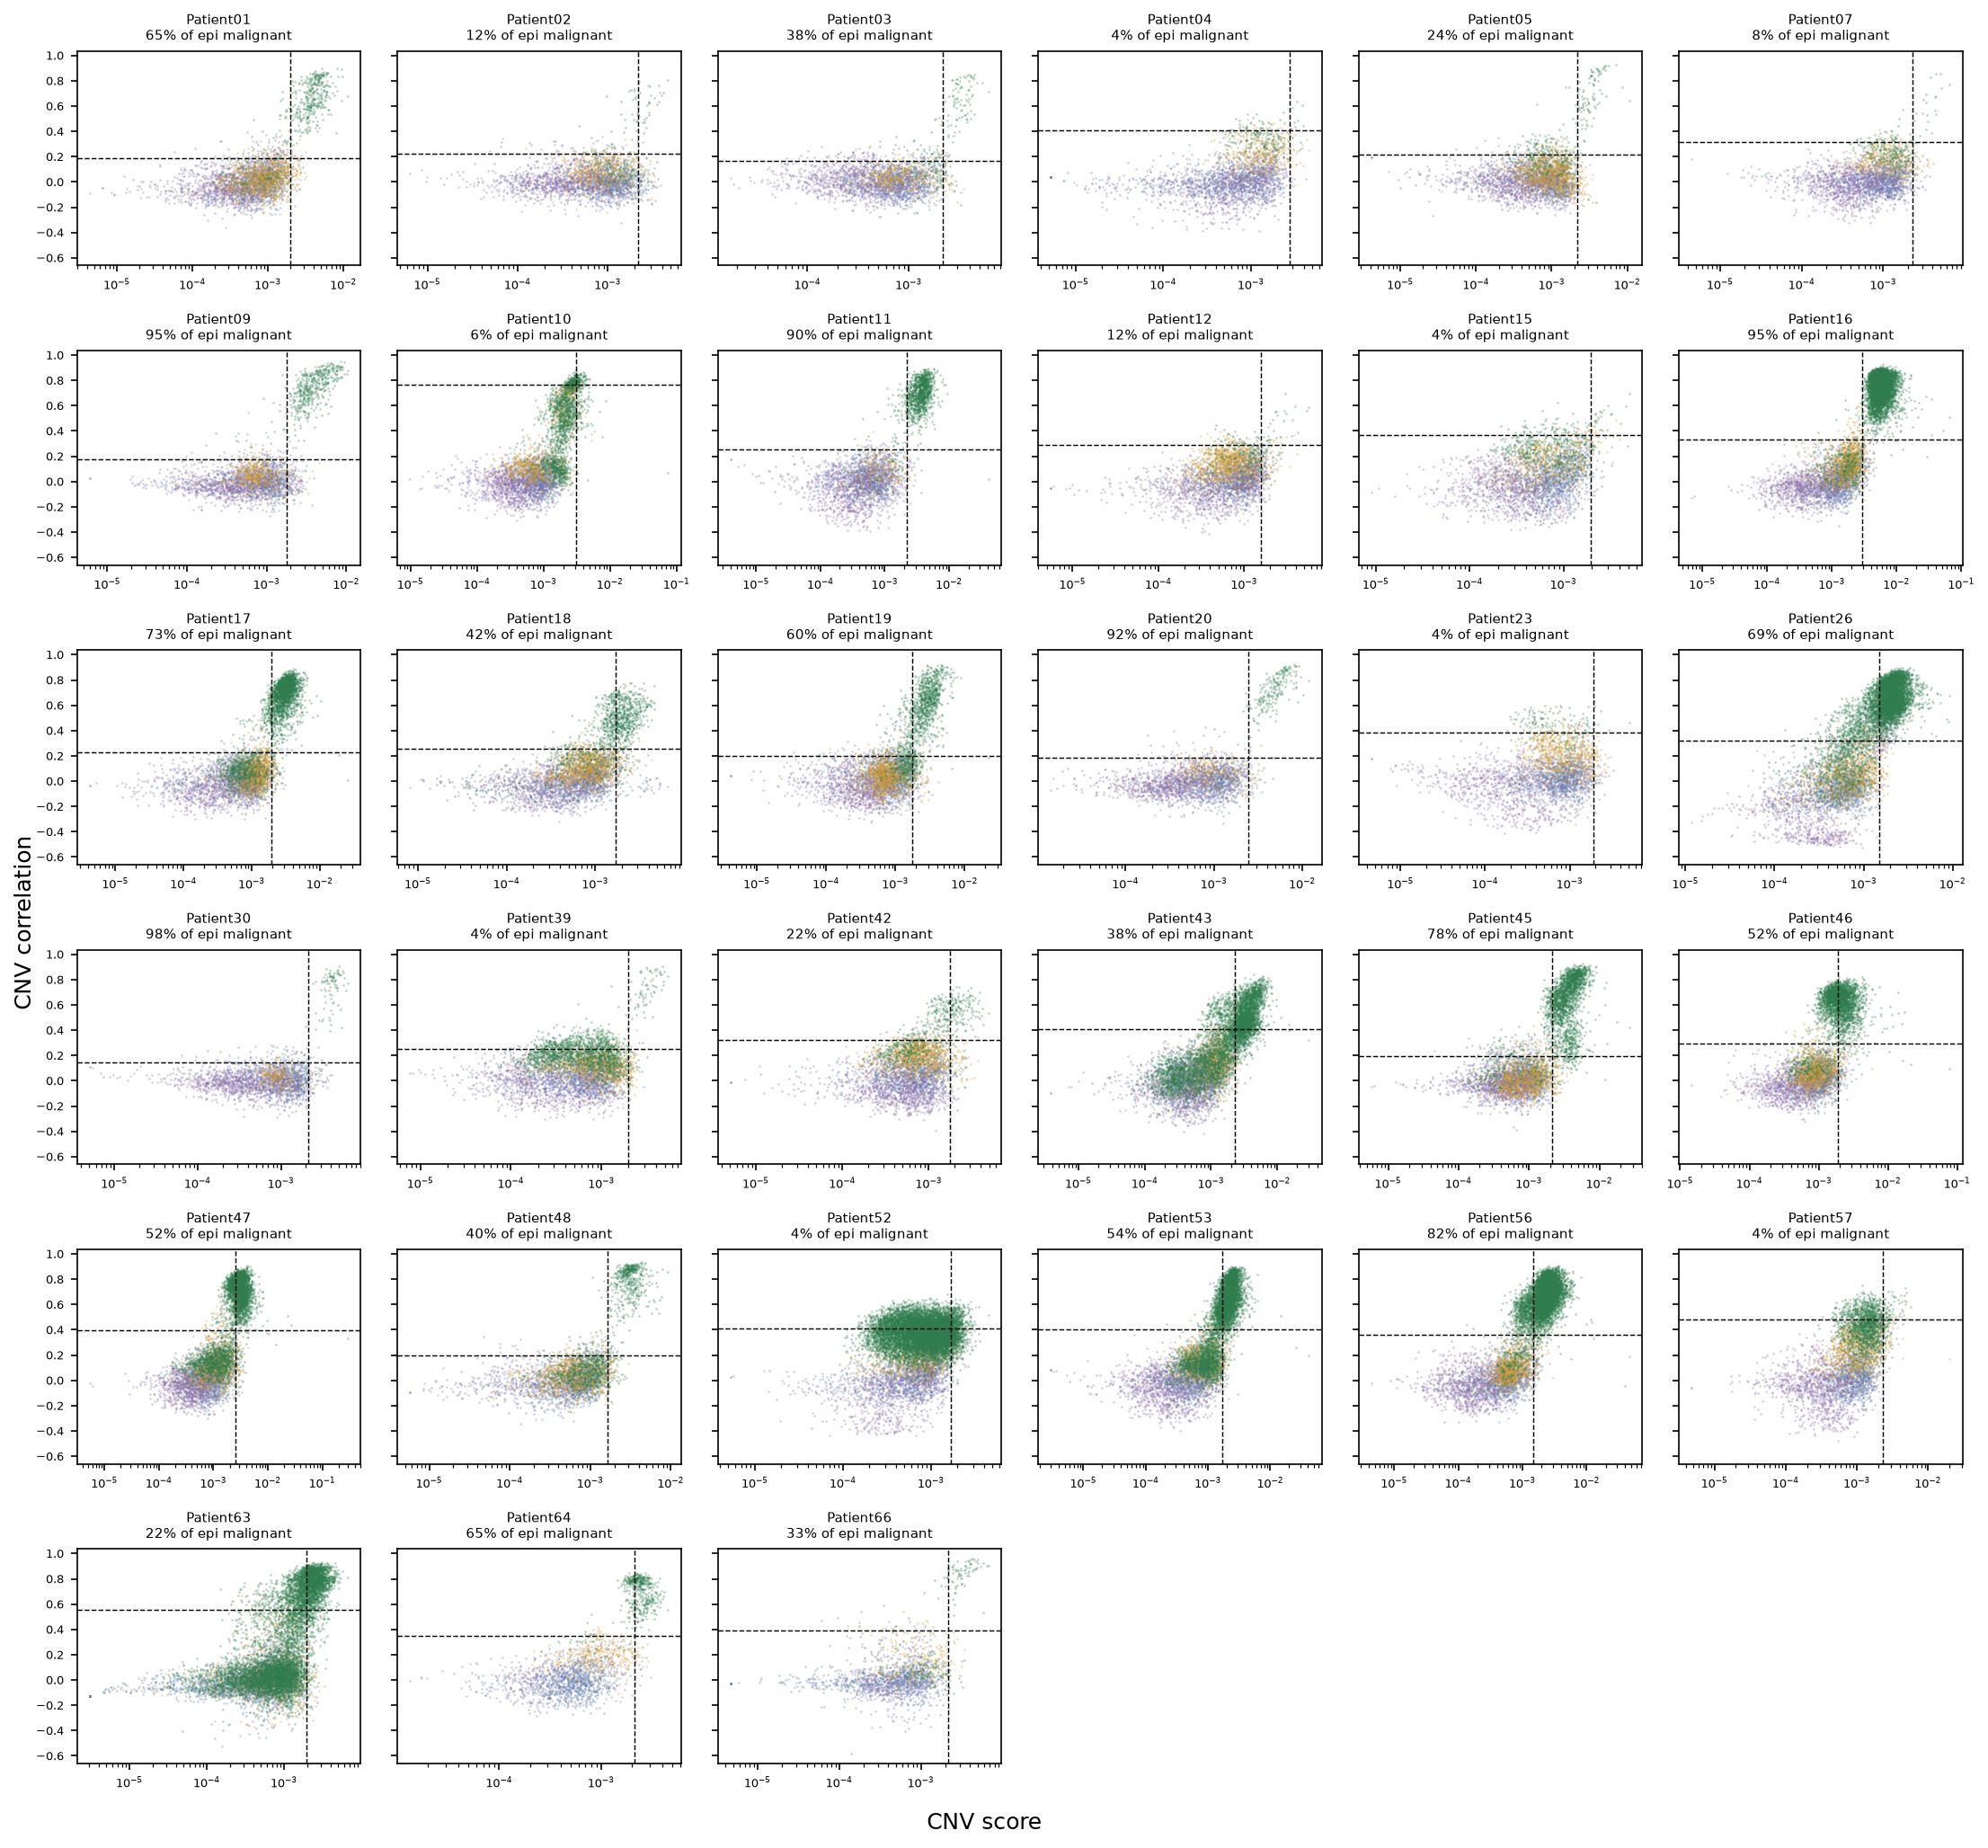

In [13]:
# Per-cohort scatter with the two cuts drawn. This is the figure to actually look at before
# accepting the call: a cohort whose epithelium sits entirely below its own cut is a cohort
# where inferCNV found no clone, and that is a real answer, not a failure to be tuned away.
cohorts = sorted(cnv['cohort'].unique())
ncol = 6
nrow = int(np.ceil(len(cohorts) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.5 * ncol, 2.3 * nrow), sharex=False, sharey=True)
for ax, cohort in zip(np.ravel(axes), cohorts):
    d = cnv[cnv['cohort'] == cohort]
    for g in [*REF_GROUPS, GROUP_STROMAL, GROUP_EPI]:
        dd = d[d['group'] == g]
        ax.scatter(dd['cnv_score'], dd['cnv_corr'], s=1.5, alpha=.35, linewidths=0,
                   color=GROUP_COLORS[g], rasterized=True)
    ax.axvline(d['cut_score'].iloc[0], color='k', lw=.7, ls='--')
    ax.axhline(d['cut_corr'].iloc[0], color='k', lw=.7, ls='--')
    frac = (d.loc[d['group'] == GROUP_EPI, 'call'] == 'malignant').mean()
    ax.set_xscale('log')
    ax.set_title(f'{cohort}\n{frac:.0%} of epi malignant', fontsize=7)
    ax.tick_params(labelsize=6)
for ax in np.ravel(axes)[len(cohorts):]:
    ax.axis('off')
fig.supxlabel('CNV score'); fig.supylabel('CNV correlation')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'cnv_call_by_cohort.png'), dpi=170)
plt.show()

<BarContainer object of 33 artists>

[Text(0, 0, 'Patient30'),
 Text(1, 0, 'Patient16'),
 Text(2, 0, 'Patient09'),
 Text(3, 0, 'Patient20'),
 Text(4, 0, 'Patient11'),
 Text(5, 0, 'Patient56'),
 Text(6, 0, 'Patient45'),
 Text(7, 0, 'Patient17'),
 Text(8, 0, 'Patient26'),
 Text(9, 0, 'Patient01'),
 Text(10, 0, 'Patient64'),
 Text(11, 0, 'Patient19'),
 Text(12, 0, 'Patient53'),
 Text(13, 0, 'Patient46'),
 Text(14, 0, 'Patient47'),
 Text(15, 0, 'Patient18'),
 Text(16, 0, 'Patient48'),
 Text(17, 0, 'Patient43'),
 Text(18, 0, 'Patient03'),
 Text(19, 0, 'Patient66'),
 Text(20, 0, 'Patient05'),
 Text(21, 0, 'Patient42'),
 Text(22, 0, 'Patient63'),
 Text(23, 0, 'Patient02'),
 Text(24, 0, 'Patient12'),
 Text(25, 0, 'Patient07'),
 Text(26, 0, 'Patient10'),
 Text(27, 0, 'Patient57'),
 Text(28, 0, 'Patient39'),
 Text(29, 0, 'Patient15'),
 Text(30, 0, 'Patient04'),
 Text(31, 0, 'Patient52'),
 Text(32, 0, 'Patient23')]

Text(0, 0.5, 'fraction of epithelium called malignant')

Text(0.5, 1.0, 'per cohort')

<BarContainer object of 10 artists>

[Text(0, 0, 'Lumsec-KIT'),
 Text(0, 1, 'Lumsec-prol'),
 Text(0, 2, 'Lumsec-basal'),
 Text(0, 3, 'LummHR-SCGB'),
 Text(0, 4, 'Lumsec-major'),
 Text(0, 5, 'LummHR-major'),
 Text(0, 6, 'basal'),
 Text(0, 7, 'Lumsec-HLA'),
 Text(0, 8, 'LummHR-active'),
 Text(0, 9, 'Lumsec-myo')]

Text(0.5, 0, 'fraction called malignant')

Text(0.5, 1.0, 'per CellTypist label from 01_4')

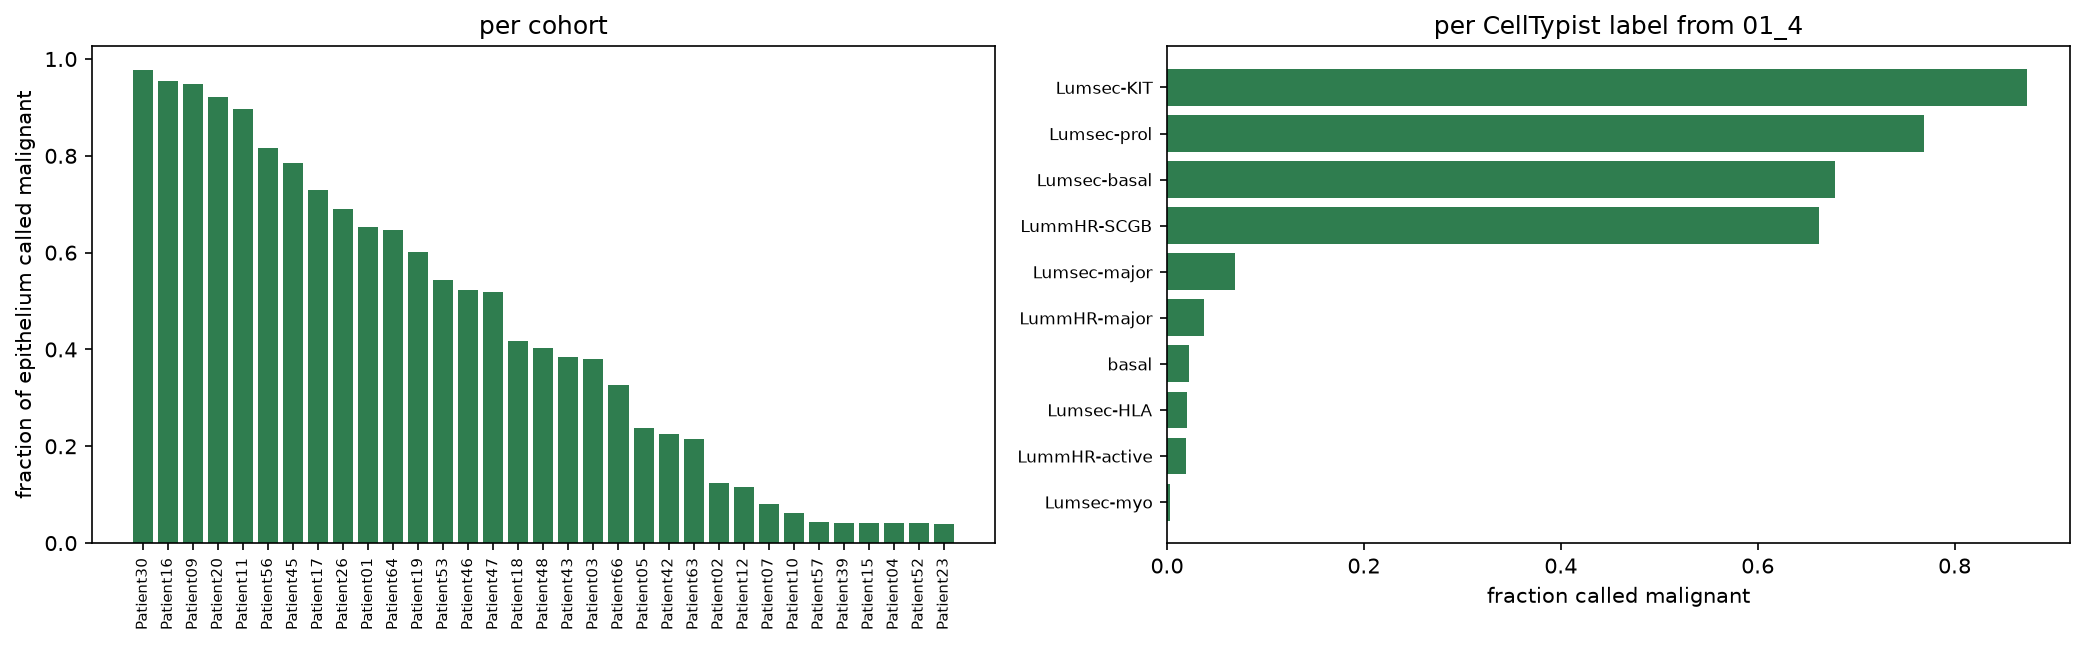

call,malignant,non_malignant
cell_type,,
LummHR-SCGB,3975,2023
LummHR-active,21,1067
LummHR-major,696,17701
Lumsec-HLA,2,95
Lumsec-KIT,1174,170
Lumsec-basal,12028,5700
Lumsec-major,98,1319
Lumsec-myo,4,1408
Lumsec-prol,18943,5703


In [14]:
# Malignant fraction per cohort, and which CellTypist labels the malignant cells were carrying.
# The second panel is the direct answer to the question 04 could not answer: the model has no
# malignant class, so it had to put these cells somewhere, and this is where.
obs = ad.read_h5ad(SHIAO_H5AD, backed='r').obs[['cell_type', 'treatment', 'response']]
epi_called = cnv[cnv['group'] == GROUP_EPI].set_index('cell').join(obs, how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
frac = (epi_called.assign(m=epi_called['call'].eq('malignant'))
        .groupby('cohort')['m'].agg(['mean', 'size']).sort_values('mean', ascending=False))
axes[0].bar(range(len(frac)), frac['mean'], color=GROUP_COLORS[GROUP_EPI])
axes[0].set_xticks(range(len(frac))); axes[0].set_xticklabels(frac.index, rotation=90, fontsize=7)
axes[0].set_ylabel('fraction of epithelium called malignant'); axes[0].set_title('per cohort')

by_label = pd.crosstab(epi_called['cell_type'], epi_called['call'], normalize='index')
by_label = by_label.reindex(columns=['malignant', 'non_malignant'], fill_value=0)
by_label = by_label.sort_values('malignant', ascending=False)
axes[1].barh(range(len(by_label)), by_label['malignant'], color=GROUP_COLORS[GROUP_EPI])
axes[1].set_yticks(range(len(by_label))); axes[1].set_yticklabels(by_label.index, fontsize=8)
axes[1].invert_yaxis(); axes[1].set_xlabel('fraction called malignant')
axes[1].set_title('per CellTypist label from 01_4')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'malignant_fraction.png'))
plt.show()

pd.crosstab(epi_called['cell_type'], epi_called['call'])

## Write the call

One row per cell **of `shiao.h5ad`**, not per cell that entered a run. Three values:

| `cnv_status` | which cells | meaning |
|---|---|---|
| `malignant` | epithelial cells above both cuts | aneuploid, one label from here on |
| `non_malignant` | everything inferCNV covered and did not call | diploid as far as this test can tell |
| `not_tested` | B/plasma cells, and every cell of a cohort no run covered | **no evidence either way** |

`not_tested` is kept as its own value rather than folded into `non_malignant` on purpose. For an
immune cell the distinction is academic, but an untested *epithelial* cell is exactly the kind of
cell this whole step exists to avoid treating as normal, and 05_2 has to be able to see it.


In [15]:
all_cells = ad.read_h5ad(SHIAO_H5AD, backed='r').obs_names
status = pd.Series('not_tested', index=all_cells, name='cnv_status')
status.loc[cnv['cell'].to_numpy()] = cnv['call'].to_numpy()

out = pd.DataFrame({'cnv_status': status})
# The two axes travel with the call: a downstream figure that wants to shade by confidence,
# or a reviewer who wants to move Q, should not have to re-read 33 summary files.
scored = cnv.set_index('cell')[['cnv_score', 'cnv_corr', 'cut_score', 'cut_corr']]
out = out.join(scored)
out.index.name = 'cell'

print(out['cnv_status'].value_counts().to_string())
print()
n_epi_untested = (out.loc[obs.index[obs['cell_type'].astype(str).isin([
    'LummHR-SCGB', 'LummHR-active', 'LummHR-major', 'Lumsec-HLA', 'Lumsec-KIT', 'Lumsec-basal',
    'Lumsec-lac', 'Lumsec-major', 'Lumsec-myo', 'Lumsec-prol', 'basal'])], 'cnv_status'] == 'not_tested').sum()
print(f'epithelial cells left untested: {n_epi_untested:,}')

out.to_csv(STATUS_OUT)
print(f'Wrote {STATUS_OUT}')

cnv_status
not_tested       454639
non_malignant    128040
malignant         37014

epithelial cells left untested: 14
Wrote /home/albertoc/Desktop/QCB-Master-Thesis/datasets/05_tum/cnv_status.csv


In [16]:
# The parameters of the call, next to the cuts they produced, so the table is readable on its
# own six months from now.
cuts_out = cuts.copy()
cuts_out['Q'] = Q
cuts_out['n_epi'] = cnv[cnv['group'] == GROUP_EPI].groupby('cohort').size()
cuts_out['n_malignant'] = (cnv[cnv['group'] == GROUP_EPI].assign(m=lambda d: d['call'].eq('malignant'))
                           .groupby('cohort')['m'].sum())
cuts_out['frac_malignant'] = cuts_out['n_malignant'] / cuts_out['n_epi']
cuts_path = os.path.join(TABLE_DIR, 'cnv_cuts_by_cohort.csv')
cuts_out.to_csv(cuts_path)
print(f'Wrote {cuts_path}')
cuts_out.round(5)

Wrote /home/albertoc/Desktop/QCB-Master-Thesis/05_drvi_tumoral_epi/tables/05_1_infercnv/cnv_cuts_by_cohort.csv


,n_stromal,null_source,cut_score,cut_corr,Q,n_epi,n_malignant,frac_malignant
cohort,,,,,,,,
Patient01,1000,own,0.00198,0.19064,0.95,542,354,0.65314
Patient02,492,own,0.00219,0.21993,0.95,209,26,0.12440
Patient03,375,own,0.00216,0.16546,0.95,234,89,0.38034
Patient04,387,own,0.00279,0.40563,0.95,192,8,0.04167
Patient05,991,own,0.00220,0.21648,0.95,376,89,0.23670
Patient07,421,own,0.00231,0.31234,0.95,257,21,0.08171
Patient09,446,own,0.00177,0.17926,0.95,471,447,0.94904
Patient10,963,own,0.00305,0.76714,0.95,1649,102,0.06186
Patient11,208,own,0.00220,0.25100,0.95,1193,1071,0.89774


## Next

```bash
conda activate benchmark-py-r
export DATA_DIR=~/Desktop/QCB-Master-Thesis/datasets
python3 recelltypist_nonmalignant.py
```

That re-runs the 01_4 CellTypist annotation on the non-malignant cells only and writes
`cell_annotation_cnv.csv`, the table 05_2 joins instead of reading `cell_type` off `shiao.h5ad`.
